1. Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points

In [1]:
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
# Numerical libraries
import numpy as np   

from sklearn.model_selection import train_test_split

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

# to handle data in form of rows and columns 
import pandas as pd    

# importing ploting libraries
import matplotlib.pyplot as plt   

#importing seaborn for statistical plots
import seaborn as sns

In [2]:
df = pd.read_csv("cars-dataset.csv")  

In [3]:
df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [4]:
df.shape

(398, 8)

In [5]:
df = df.loc[df['hp'] != '?', :]  # remove all the ? values from the dataset

In [6]:
df.shape

(392, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
car name    392 non-null object
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null object
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 27.6+ KB


In [8]:
df['hp'] = df['hp'].astype('float64')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
car name    392 non-null object
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null float64
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 27.6+ KB


In [10]:
mpg_df = df

In [11]:

numeric_cols = mpg_df.drop('car name', axis=1)

# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
car_names = pd.DataFrame(mpg_df[['car name']])


numeric_cols = numeric_cols.apply(lambda x: x.fillna(x.median()),axis=0)
mpg_df = numeric_cols.join(car_names)   # Recreating mpg_df by combining numerical columns with car names

mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null float64
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
car name    392 non-null object
dtypes: float64(4), int64(3), object(1)
memory usage: 37.6+ KB


In [12]:
mpg_df.head()


,cyl,disp,hp,wt,acc,yr,mpg,car name
0,8,307.0,130.0,3504,12.0,70,18.0,chevrolet chevelle malibu
1,8,350.0,165.0,3693,11.5,70,15.0,buick skylark 320
2,8,318.0,150.0,3436,11.0,70,18.0,plymouth satellite
3,8,304.0,150.0,3433,12.0,70,16.0,amc rebel sst
4,8,302.0,140.0,3449,10.5,70,17.0,ford torino


2. Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points

In [13]:
mpg_df_attr = mpg_df.iloc[:, 0:9]
mpg_df_attr['dispercyl'] = mpg_df_attr['disp'] / mpg_df_attr['cyl']

C:\Users\v.rajan\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


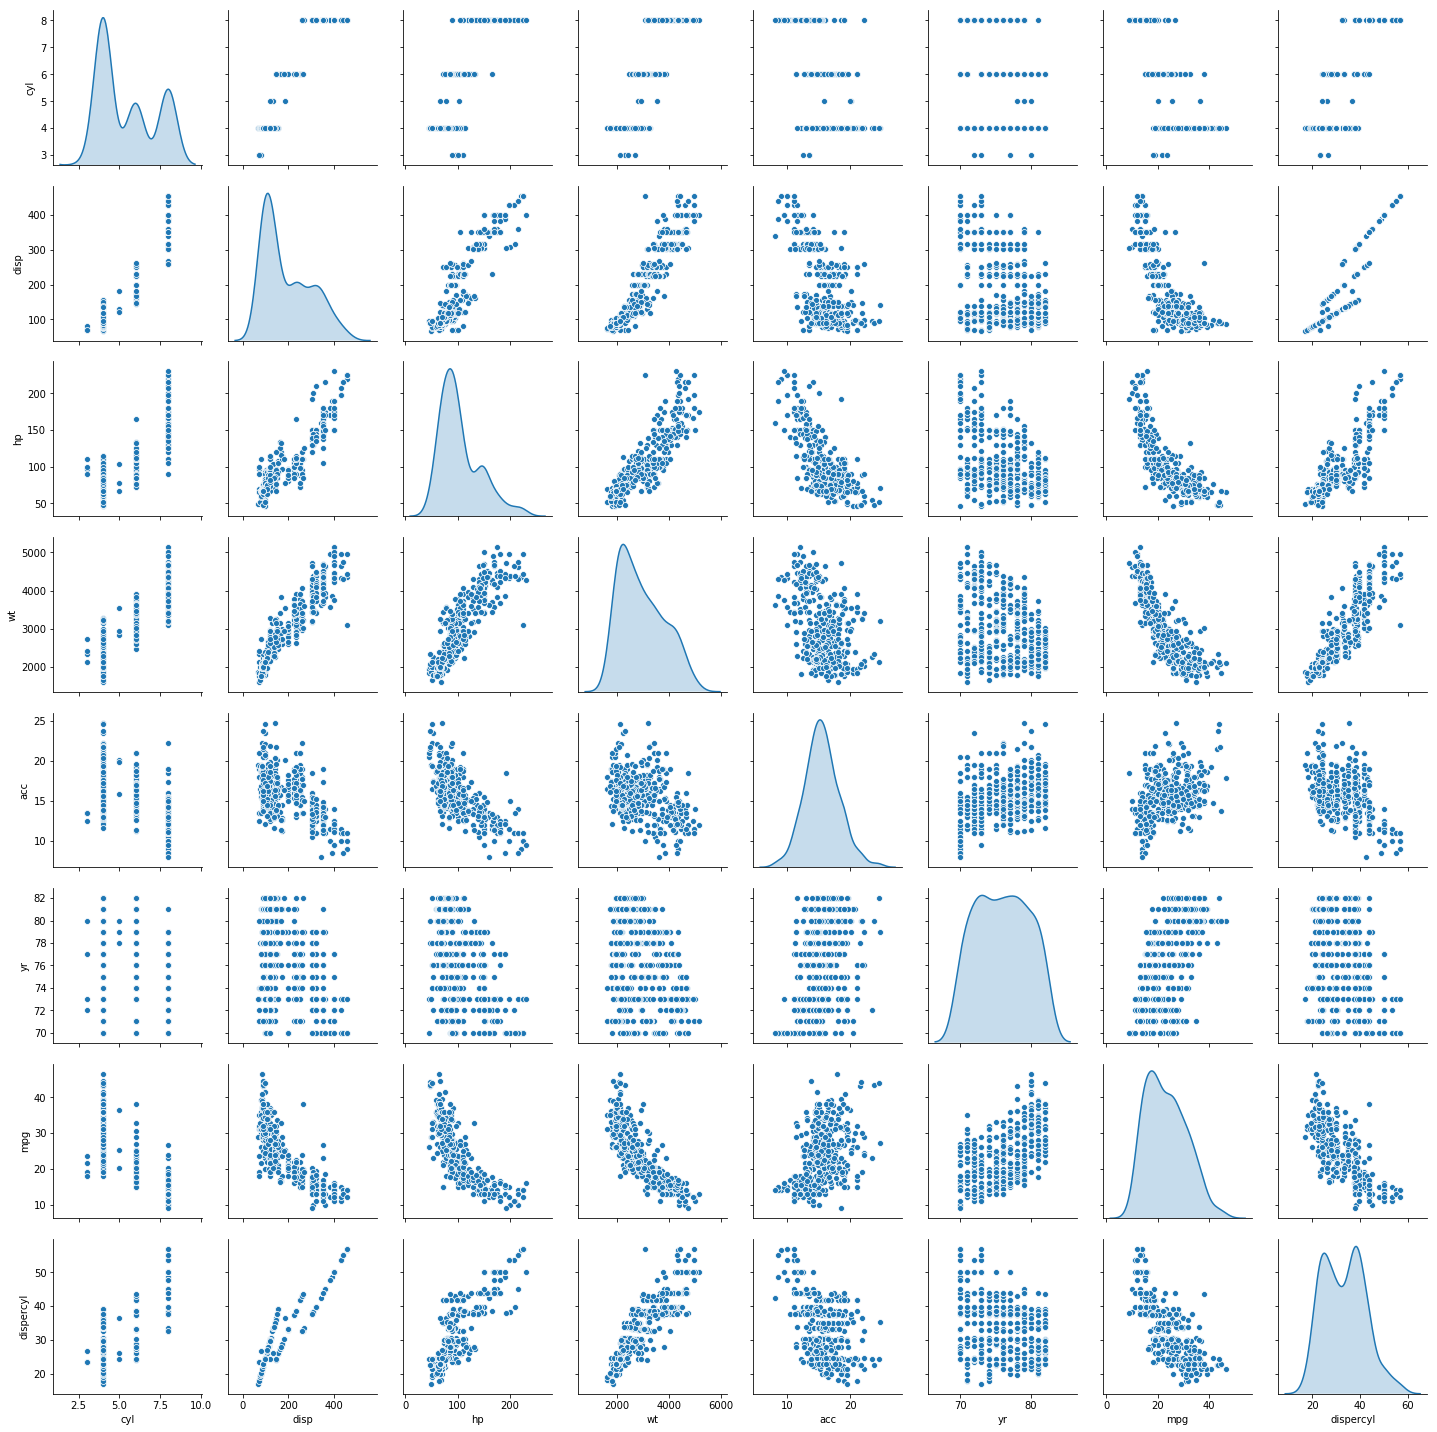

In [14]:
sns.pairplot(mpg_df_attr, diag_kind='kde')


3. Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)
4. Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [15]:
from scipy.stats import zscore

mpg_df_attr = mpg_df.loc[:, 'cyl':'mpg']
mpg_df_attr_z = mpg_df_attr.apply(zscore)

#mpg_df_attr_z.pop('origin')      # Remove "origin" and "yr" columns
mpg_df_attr_z.pop('yr')

array = mpg_df_attr_z.values
X = array[:,1:5] # select all rows and first 7 columns which are the attributes
y = array[:,0]   # select all rows and the 8th column which is the classification "Yes", "No" for diabeties
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)


In [16]:
cluster_range = range( 2, 6)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(mpg_df_attr)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,7.292105e+07
1,3,3.384903e+07
2,4,1.881101e+07
3,5,1.350093e+07


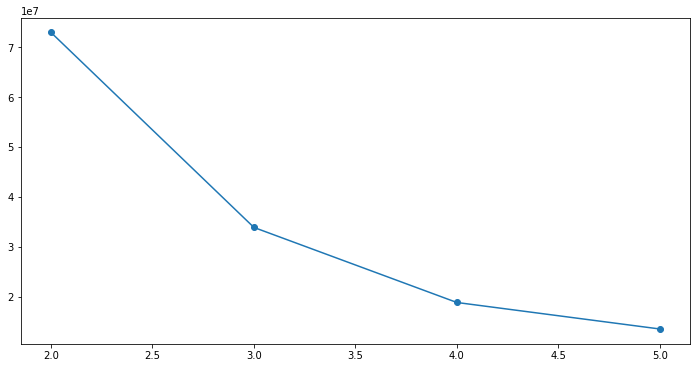

In [17]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [18]:
# The elbow plot confirms our visual analysis that there are likely 3 or 4 good clusters
# Let us start with 3 clusters

In [19]:
cluster = KMeans( n_clusters = 3, random_state = 2354 )
cluster.fit(mpg_df_attr_z)
mpg_df_attr_z_copy = mpg_df_attr_z.copy(deep = True)

In [20]:
centroids = cluster.cluster_centers_
centroids

array([[ 1.47184414,  1.46979213,  1.49145953,  1.37493755, -1.05253303,
        -1.14393843],
       [-0.86110766, -0.81098162, -0.6843036 , -0.79514908,  0.36356374,
         0.76382895],
       [ 0.33521362,  0.22847796, -0.06927147,  0.29302334,  0.30812718,
        -0.46592926]])

In [21]:
centroid_df = pd.DataFrame(centroids, columns = list(mpg_df_attr_z) )
centroid_df

,cyl,disp,hp,wt,acc,mpg
0,1.471844,1.469792,1.491460,1.374938,-1.052533,-1.143938
1,-0.861108,-0.810982,-0.684304,-0.795149,0.363564,0.763829
2,0.335214,0.228478,-0.069271,0.293023,0.308127,-0.465929


In [22]:
prediction=cluster.predict(mpg_df_attr_z)
mpg_df_attr_z["GROUP"] = prediction  